<a href="https://colab.research.google.com/github/catalinagaviriamet-spec/Ciencia-de-datos/blob/main/Ejercicio_DataAdults.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercicio Datos Sociodemográficos de adultos

Primera entrega para el módulo Proyecto I


Integrantes:
Yerlith Judith Zabala Martinez,
Carolina Tirado Osorio,
Ana Catalina Gaviria Metaute.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

columnas_es = [
    "edad",
    "tipo_trabajo",
    "peso_muestral",
    "nivel_educativo",
    "anios_educacion",
    "estado_civil",
    "ocupacion",
    "relacion_familiar",
    "raza",
    "sexo",
    "ganancia_capital",
    "perdida_capital",
    "horas_por_semana",
    "pais_origen",
    "ingresos"
]

df = pd.read_csv(url, header=None, names=columnas_es)
df.head()

print('Shape inicial:', df.shape)
display(df.head())

Shape inicial: (48842, 15)


,edad,tipo_trabajo,peso_muestral,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,raza,sexo,ganancia_capital,perdida_capital,horas_por_semana,pais_origen,ingresos
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Se muestra que la base de datos elegida contiene un total de 48,842 registros con 15 columnas.

**Exploración Inicial del dataset**: estructura, estadística y valores faltantes

In [2]:
df.describe()

,edad,peso_muestral,anios_educacion,ganancia_capital,perdida_capital,horas_por_semana
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Del resumen numérico se observa lo siguiente:
1. La edad promedio de las persona es de 38 años, y en promedio han cursado 10 años de educación.
2. La edad mínima de la población de de 17 años y la máxima es de 90.
3. En promedio las personas trabajan 40 horas a la semana, y el máximo de horas trabajadas son 99.
4. Comparando los mínimos y los máximos contra los cuartiles, así como la desviación estándar respecto a la media, se identifican valores outliers en las columnas edad, ganancia_capital, perdida_capital y horas_por_semana, debido a que los máximos están muy alejados del q3 y la std para algunas viriables está muy alta respecto a la media.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   edad               48842 non-null  int64 
 1   tipo_trabajo       48842 non-null  object
 2   peso_muestral      48842 non-null  int64 
 3   nivel_educativo    48842 non-null  object
 4   anios_educacion    48842 non-null  int64 
 5   estado_civil       48842 non-null  object
 6   ocupacion          48842 non-null  object
 7   relacion_familiar  48842 non-null  object
 8   raza               48842 non-null  object
 9   sexo               48842 non-null  object
 10  ganancia_capital   48842 non-null  int64 
 11  perdida_capital    48842 non-null  int64 
 12  horas_por_semana   48842 non-null  int64 
 13  pais_origen        48842 non-null  object
 14  ingresos           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
edad,0
tipo_trabajo,0
peso_muestral,0
nivel_educativo,0
anios_educacion,0
estado_civil,0
ocupacion,0
relacion_familiar,0
raza,0
sexo,0


Se observa que de las 15 variables del dataset, el 40% son numéricas, y el 60% son categóricas. Adicionalmente, ninguna de las variables tiene valores nulos.

In [4]:
df.isin(["?"]).sum()

,0
edad,0
tipo_trabajo,2799
peso_muestral,0
nivel_educativo,0
anios_educacion,0
estado_civil,0
ocupacion,2809
relacion_familiar,0
raza,0
sexo,0


In [5]:
df.replace("?", pd.NA, inplace=True)

Se identifican valores con el caracter "?" y se reemplazan por NA.

In [6]:
print('\nResumen categórico:')
display(df.describe(include='object'))


Resumen categórico:


,tipo_trabajo,nivel_educativo,estado_civil,ocupacion,relacion_familiar,raza,sexo,pais_origen,ingresos
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


Según el resumen categórico, se tienen 9 tipos de trabajo, 7 estados civiles, 15 ocupaciones, entre otros. En el top de tipo_trabajo resalta el Private, y la base tiene mas hombres que mujeres. Adicional, el país_origen que mas se presenta es Estados Unidos.

**Análisis descriptivo y resumenes pivotes**: Distribución de valores por columna

In [7]:
for col in df.columns:
    print(f"\n🔹 {col}")
    print(df[col].value_counts())


🔹 edad
edad
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

🔹 tipo_trabajo
tipo_trabajo
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

🔹 peso_muestral
peso_muestral
203488    21
120277    19
190290    19
126569    18
125892    18
          ..
275677     1
311631     1
374763     1
242136     1
26711      1
Name: count, Length: 28523, dtype: int64

🔹 nivel_educativo
nivel_educativo
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th

In [8]:
cols = ["relacion_familiar", "raza", "sexo", "pais_origen"]

for col in cols:
    print(f"\n🔹 {col.upper()}")
    print(df[col].value_counts())


🔹 RELACION_FAMILIAR
relacion_familiar
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64

🔹 RAZA
raza
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

🔹 SEXO
sexo
Male      32650
Female    16192
Name: count, dtype: int64

🔹 PAIS_ORIGEN
pais_origen
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-

Proporciones % Genero, pais, sexo.

In [9]:
for col in cols:
    print(f"\n🔹 {col.upper()} (%)")
    print((df[col].value_counts(normalize=True)*100).round(2))


🔹 RELACION_FAMILIAR (%)
relacion_familiar
Husband           40.37
Not-in-family     25.76
Own-child         15.52
Unmarried         10.49
Wife               4.77
Other-relative     3.08
Name: proportion, dtype: float64

🔹 RAZA (%)
raza
White                 85.50
Black                  9.59
Asian-Pac-Islander     3.11
Amer-Indian-Eskimo     0.96
Other                  0.83
Name: proportion, dtype: float64

🔹 SEXO (%)
sexo
Male      66.85
Female    33.15
Name: proportion, dtype: float64

🔹 PAIS_ORIGEN (%)
pais_origen
United-States                 91.35
Mexico                         1.98
Philippines                    0.61
Germany                        0.43
Puerto-Rico                    0.38
Canada                         0.38
El-Salvador                    0.32
India                          0.31
Cuba                           0.29
England                        0.26
China                          0.25
South                          0.24
Jamaica                        0.22
Italy    

In [10]:
df["horas_por_semana"].value_counts().head(10)

,count
horas_por_semana,
40,22803
50,4246
45,2717
60,2177
35,1937
20,1862
30,1700
55,1051
25,958


Sexo vs ingresos

In [11]:
pd.crosstab(df["sexo"], df["ingresos"], normalize="index")*100

ingresos,<=50K,>50K
sexo,,
Female,89.074852,10.925148
Male,69.623277,30.376723


Top Paises


In [12]:
top_paises = df["pais_origen"].value_counts().head(5).index

pd.crosstab(df[df["pais_origen"].isin(top_paises)]["pais_origen"],
            df["ingresos"], normalize="index")*100

ingresos,<=50K,>50K
pais_origen,,
Germany,71.844660,28.155340
Mexico,95.057834,4.942166
Philippines,71.186441,28.813559
Puerto-Rico,89.130435,10.869565
United-States,75.602300,24.397700


“En promedio, quienes ganan más trabajan X horas vs Y horas”

In [13]:
df.groupby("ingresos")["horas_por_semana"].mean()

,horas_por_semana
ingresos,
<=50K,38.840048
>50K,45.452896


“El análisis exploratorio muestra diferencias importantes en la distribución de ingresos según variables demográficas como género, relación familiar y país de origen, además de una relación con la cantidad de horas trabajadas.”

**Calidad de datos**: nulos, duplicados y algunas validaciones básicas

In [14]:
df.isna().sum()

,0
edad,0
tipo_trabajo,2799
peso_muestral,0
nivel_educativo,0
anios_educacion,0
estado_civil,0
ocupacion,2809
relacion_familiar,0
raza,0
sexo,0


In [15]:
df.nunique(dropna=False)

,0
edad,74
tipo_trabajo,9
peso_muestral,28523
nivel_educativo,16
anios_educacion,16
estado_civil,7
ocupacion,15
relacion_familiar,6
raza,5
sexo,2


In [16]:
quality = pd.DataFrame({
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2),
    'n_unicos': df.nunique(dropna=False)
}).sort_values('pct_nulos', ascending=False)

display(quality)

print('Filas duplicadas:', df.duplicated().sum())
print('ganancia_capital negativos:', (df['ganancia_capital'] < 0).sum())
print('edad negativos:', (df['edad'] < 0).sum())
print('horas_por_semana negativos:', (df['horas_por_semana'] < 0).sum())

,nulos,pct_nulos,n_unicos
ocupacion,2809,5.75,15
tipo_trabajo,2799,5.73,9
pais_origen,857,1.75,42
peso_muestral,0,0.00,28523
nivel_educativo,0,0.00,16
anios_educacion,0,0.00,16
edad,0,0.00,74
estado_civil,0,0.00,7
relacion_familiar,0,0.00,6
sexo,0,0.00,2


Filas duplicadas: 52
ganancia_capital negativos: 0
edad negativos: 0
horas_por_semana negativos: 0


Se identifica 52 filas duplicadas que se deben eliminar, y se comprueba que no hay valores negativos incongruentes.

**Limpieza de datos**: eliminación de filas; agrupación de categorías para mejor análisis.

In [17]:
df = df.drop_duplicates()
print('Shape final:', df.shape)
display(df.head())

Shape final: (48790, 15)


,edad,tipo_trabajo,peso_muestral,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,raza,sexo,ganancia_capital,perdida_capital,horas_por_semana,pais_origen,ingresos
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Se eliminan las 52 filas repetidas, quedando con un dataset de 48,790 registros

**Feature engineering**: crear nuevas variables para mejorar el análisis

In [18]:
region_map = {
    # Norteamérica
    "United-States": "Norteamérica",
    "Canada": "Norteamérica",
    "Mexico": "Norteamérica",
    "Puerto-Rico": "Norteamérica",
    "Outlying-US(Guam-USVI-etc)": "Norteamérica",

    # Latinoamérica y Caribe
    "El-Salvador": "Latinoamérica",
    "Cuba": "Latinoamérica",
    "Jamaica": "Latinoamérica",
    "Dominican-Republic": "Latinoamérica",
    "Guatemala": "Latinoamérica",
    "Haiti": "Latinoamérica",
    "Nicaragua": "Latinoamérica",
    "Peru": "Latinoamérica",
    "Ecuador": "Latinoamérica",
    "Columbia": "Latinoamérica",
    "Honduras": "Latinoamérica",
    "Trinadad&Tobago": "Latinoamérica",

    # Europa
    "Germany": "Europa",
    "England": "Europa",
    "Italy": "Europa",
    "Poland": "Europa",
    "Portugal": "Europa",
    "Greece": "Europa",
    "France": "Europa",
    "Ireland": "Europa",
    "Scotland": "Europa",
    "Hungary": "Europa",
    "Yugoslavia": "Europa",
    "Holand-Netherlands": "Europa",

    # Asia
    "Philippines": "Asia",
    "India": "Asia",
    "China": "Asia",
    "Japan": "Asia",
    "Vietnam": "Asia",
    "Taiwan": "Asia",
    "Iran": "Asia",
    "Thailand": "Asia",
    "Hong": "Asia",
    "Cambodia": "Asia",
    "Laos": "Asia",

    # Otros
    "South": "Otros"
}
df["region"] = df["pais_origen"].map(region_map)
df['region'].value_counts()

,count
region,
Norteamérica,45124
Asia,980
Latinoamérica,935
Europa,780
Otros,115


In [19]:
bins = [16, 25, 35, 60, 99]
labels = ['Joven', 'Joven adulto', 'Adulto', 'Adulto mayor']
df["grupo_edad"] = pd.cut(
    df["edad"],
    bins=bins,
    labels=labels,
    right=True
)

df['horas_por_semana_grupo'] = pd.cut(
    df['horas_por_semana'],
    bins=[0, 25, 40, 60, 100],
    labels=['tiempo_parcial', 'estandar', 'extendido', 'muy_alto'],
    include_lowest=True
)

df['es_casado'] = np.where(
    df['estado_civil'].astype(str).str.contains(
        'Married-civ-spouse|Married-spouse-absent|Married-AF-spouse',
        case=False,
        na=False,
        regex=True
    ),
    1,
    0
)

df['balance_de_capital'] = df['ganancia_capital'] - df['perdida_capital']

df['tiene_cambio_de_capital'] = np.where((df['ganancia_capital'] > 0) | (df['perdida_capital'] > 0),1,0)

df['educacion_vs_edad'] = df['anios_educacion'] / df['edad']

df[['region','grupo_edad', 'horas_por_semana_grupo', 'es_casado', 'balance_de_capital', 'tiene_cambio_de_capital', 'educacion_vs_edad']].head()

,region,grupo_edad,horas_por_semana_grupo,es_casado,balance_de_capital,tiene_cambio_de_capital,educacion_vs_edad
0,Norteamérica,Adulto,estandar,0,2174,1,0.333333
1,Norteamérica,Adulto,tiempo_parcial,1,0,0,0.260000
2,Norteamérica,Adulto,estandar,0,0,0,0.236842
3,Norteamérica,Adulto,estandar,1,0,0,0.132075
4,Latinoamérica,Joven adulto,estandar,1,0,0,0.464286


In [20]:
columns_to_drop = [
    'peso_muestral',
    'raza',
    'pais_origen',
    'horas_por_semana',
    'ganancia_capital',
    'perdida_capital'
    # Explicitly add 'ingresos' now that 'apto_credito' is created earlier
]

# Eliminar columnas que existen en el DataFrame
cols_to_actually_drop = [col for col in columns_to_drop if col in df.columns]
if cols_to_actually_drop:
    df = df.drop(columns=cols_to_actually_drop)

# Llenar valores NA para 'tipo_trabajo' y 'ocupacion'
for col in ['tipo_trabajo', 'ocupacion']:
    if col in df.columns: # Verificar si la columna todavía existe
        df[col] = df[col].fillna('unknown')

print("DataFrame después de eliminar columnas innecesarias y limpiar valores NA:")
print('Shape final:', df.shape)
display(df.head())

DataFrame después de eliminar columnas innecesarias y limpiar valores NA:
Shape final: (48790, 16)


,edad,tipo_trabajo,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,sexo,ingresos,region,grupo_edad,horas_por_semana_grupo,es_casado,balance_de_capital,tiene_cambio_de_capital,educacion_vs_edad
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,2174,1,0.333333
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,<=50K,Norteamérica,Adulto,tiempo_parcial,1,0,0,0.260000
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,0,0,0.236842
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,<=50K,Norteamérica,Adulto,estandar,1,0,0,0.132075
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,<=50K,Latinoamérica,Joven adulto,estandar,1,0,0,0.464286


In [21]:
df

,edad,tipo_trabajo,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,sexo,ingresos,region,grupo_edad,horas_por_semana_grupo,es_casado,balance_de_capital,tiene_cambio_de_capital,educacion_vs_edad
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,2174,1,0.333333
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,<=50K,Norteamérica,Adulto,tiempo_parcial,1,0,0,0.260000
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,0,0,0.236842
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,<=50K,Norteamérica,Adulto,estandar,1,0,0,0.132075
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,<=50K,Latinoamérica,Joven adulto,estandar,1,0,0,0.464286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,Bachelors,13,Divorced,Prof-specialty,Not-in-family,Female,<=50K,Norteamérica,Adulto,estandar,0,0,0,0.333333
48838,64,unknown,HS-grad,9,Widowed,unknown,Other-relative,Male,<=50K,Norteamérica,Adulto mayor,estandar,0,0,0,0.140625
48839,38,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,Male,<=50K,Norteamérica,Adulto,extendido,1,0,0,0.342105
48840,44,Private,Bachelors,13,Divorced,Adm-clerical,Own-child,Male,<=50K,Norteamérica,Adulto,estandar,0,5455,1,0.295455


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   edad                     48790 non-null  int64   
 1   tipo_trabajo             48790 non-null  object  
 2   nivel_educativo          48790 non-null  object  
 3   anios_educacion          48790 non-null  int64   
 4   estado_civil             48790 non-null  object  
 5   ocupacion                48790 non-null  object  
 6   relacion_familiar        48790 non-null  object  
 7   sexo                     48790 non-null  object  
 8   ingresos                 48790 non-null  object  
 9   region                   47934 non-null  object  
 10  grupo_edad               48790 non-null  category
 11  horas_por_semana_grupo   48790 non-null  category
 12  es_casado                48790 non-null  int64   
 13  balance_de_capital       48790 non-null  int64   
 14  tiene_cambi

In [23]:
df.isna().sum().sort_values(ascending=False).head(15)

,0
region,856
edad,0
nivel_educativo,0
tipo_trabajo,0
estado_civil,0
ocupacion,0
relacion_familiar,0
anios_educacion,0
sexo,0
ingresos,0


## Tratamiento de datos faltantes

In [24]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

In [25]:
imputer_constant = SimpleImputer(strategy='constant', fill_value='missing')

In [26]:
df.head(10)

,edad,tipo_trabajo,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,sexo,ingresos,region,grupo_edad,horas_por_semana_grupo,es_casado,balance_de_capital,tiene_cambio_de_capital,educacion_vs_edad
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,2174,1,0.333333
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,<=50K,Norteamérica,Adulto,tiempo_parcial,1,0,0,0.260000
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,0,0,0.236842
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,<=50K,Norteamérica,Adulto,estandar,1,0,0,0.132075
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,<=50K,Latinoamérica,Joven adulto,estandar,1,0,0,0.464286
5,37,Private,Masters,14,Married-civ-spouse,Exec-managerial,Wife,Female,<=50K,Norteamérica,Adulto,estandar,1,0,0,0.378378
6,49,Private,9th,5,Married-spouse-absent,Other-service,Not-in-family,Female,<=50K,Latinoamérica,Adulto,tiempo_parcial,1,0,0,0.102041
7,52,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,Male,>50K,Norteamérica,Adulto,extendido,1,0,0,0.173077
8,31,Private,Masters,14,Never-married,Prof-specialty,Not-in-family,Female,>50K,Norteamérica,Joven adulto,extendido,0,14084,1,0.451613
9,42,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,>50K,Norteamérica,Adulto,estandar,1,5178,1,0.309524


In [27]:
df_imputed_demo = df.copy()
cat_demo_cols = df_imputed_demo.select_dtypes(include=['object', 'category']).columns.tolist() + ['horas_por_semana_grupo']
num_demo_cols = df_imputed_demo.select_dtypes(exclude=['object', 'category']).columns.tolist()

df_imputed_demo[cat_demo_cols] = imputer_constant.fit_transform(df_imputed_demo[cat_demo_cols])
df_imputed_demo[num_demo_cols] = SimpleImputer(strategy='median').fit_transform(df_imputed_demo[num_demo_cols])
df_imputed_demo.head()

,edad,tipo_trabajo,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,sexo,ingresos,region,grupo_edad,horas_por_semana_grupo,es_casado,balance_de_capital,tiene_cambio_de_capital,educacion_vs_edad
0,39.0,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0.0,2174.0,1.0,0.333333
1,50.0,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,Male,<=50K,Norteamérica,Adulto,tiempo_parcial,1.0,0.0,0.0,0.260000
2,38.0,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0.0,0.0,0.0,0.236842
3,53.0,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Male,<=50K,Norteamérica,Adulto,estandar,1.0,0.0,0.0,0.132075
4,28.0,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Female,<=50K,Latinoamérica,Joven adulto,estandar,1.0,0.0,0.0,0.464286


## One-hot-encoder


In [28]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

nominal_cols = ['tipo_trabajo', 'nivel_educativo', 'ocupacion']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
nominal_encoded = ohe.fit_transform(df[nominal_cols])
nominal_encoded[:3]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.]])

In [29]:
ohe.get_feature_names_out(nominal_cols)

array(['tipo_trabajo_Local-gov', 'tipo_trabajo_Never-worked',
       'tipo_trabajo_Private', 'tipo_trabajo_Self-emp-inc',
       'tipo_trabajo_Self-emp-not-inc', 'tipo_trabajo_State-gov',
       'tipo_trabajo_Without-pay', 'tipo_trabajo_unknown',
       'nivel_educativo_11th', 'nivel_educativo_12th',
       'nivel_educativo_1st-4th', 'nivel_educativo_5th-6th',
       'nivel_educativo_7th-8th', 'nivel_educativo_9th',
       'nivel_educativo_Assoc-acdm', 'nivel_educativo_Assoc-voc',
       'nivel_educativo_Bachelors', 'nivel_educativo_Doctorate',
       'nivel_educativo_HS-grad', 'nivel_educativo_Masters',
       'nivel_educativo_Preschool', 'nivel_educativo_Prof-school',
       'nivel_educativo_Some-college', 'ocupacion_Armed-Forces',
       'ocupacion_Craft-repair', 'ocupacion_Exec-managerial',
       'ocupacion_Farming-fishing', 'ocupacion_Handlers-cleaners',
       'ocupacion_Machine-op-inspct', 'ocupacion_Other-service',
       'ocupacion_Priv-house-serv', 'ocupacion_Prof-specialty'

In [30]:
nominal_df = pd.DataFrame(
    nominal_encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=df.index
)
nominal_df.head()

,tipo_trabajo_Local-gov,tipo_trabajo_Never-worked,tipo_trabajo_Private,tipo_trabajo_Self-emp-inc,tipo_trabajo_Self-emp-not-inc,tipo_trabajo_State-gov,tipo_trabajo_Without-pay,tipo_trabajo_unknown,nivel_educativo_11th,nivel_educativo_12th,...,ocupacion_Handlers-cleaners,ocupacion_Machine-op-inspct,ocupacion_Other-service,ocupacion_Priv-house-serv,ocupacion_Prof-specialty,ocupacion_Protective-serv,ocupacion_Sales,ocupacion_Tech-support,ocupacion_Transport-moving,ocupacion_unknown
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [31]:
pd.concat([df[nominal_cols].head(), nominal_df.head()], axis=1)

,tipo_trabajo,nivel_educativo,ocupacion,tipo_trabajo_Local-gov,tipo_trabajo_Never-worked,tipo_trabajo_Private,tipo_trabajo_Self-emp-inc,tipo_trabajo_Self-emp-not-inc,tipo_trabajo_State-gov,tipo_trabajo_Without-pay,...,ocupacion_Handlers-cleaners,ocupacion_Machine-op-inspct,ocupacion_Other-service,ocupacion_Priv-house-serv,ocupacion_Prof-specialty,ocupacion_Protective-serv,ocupacion_Sales,ocupacion_Tech-support,ocupacion_Transport-moving,ocupacion_unknown
0,State-gov,Bachelors,Adm-clerical,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Self-emp-not-inc,Bachelors,Exec-managerial,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Private,HS-grad,Handlers-cleaners,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Private,11th,Handlers-cleaners,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Private,Bachelors,Prof-specialty,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Escalamiento

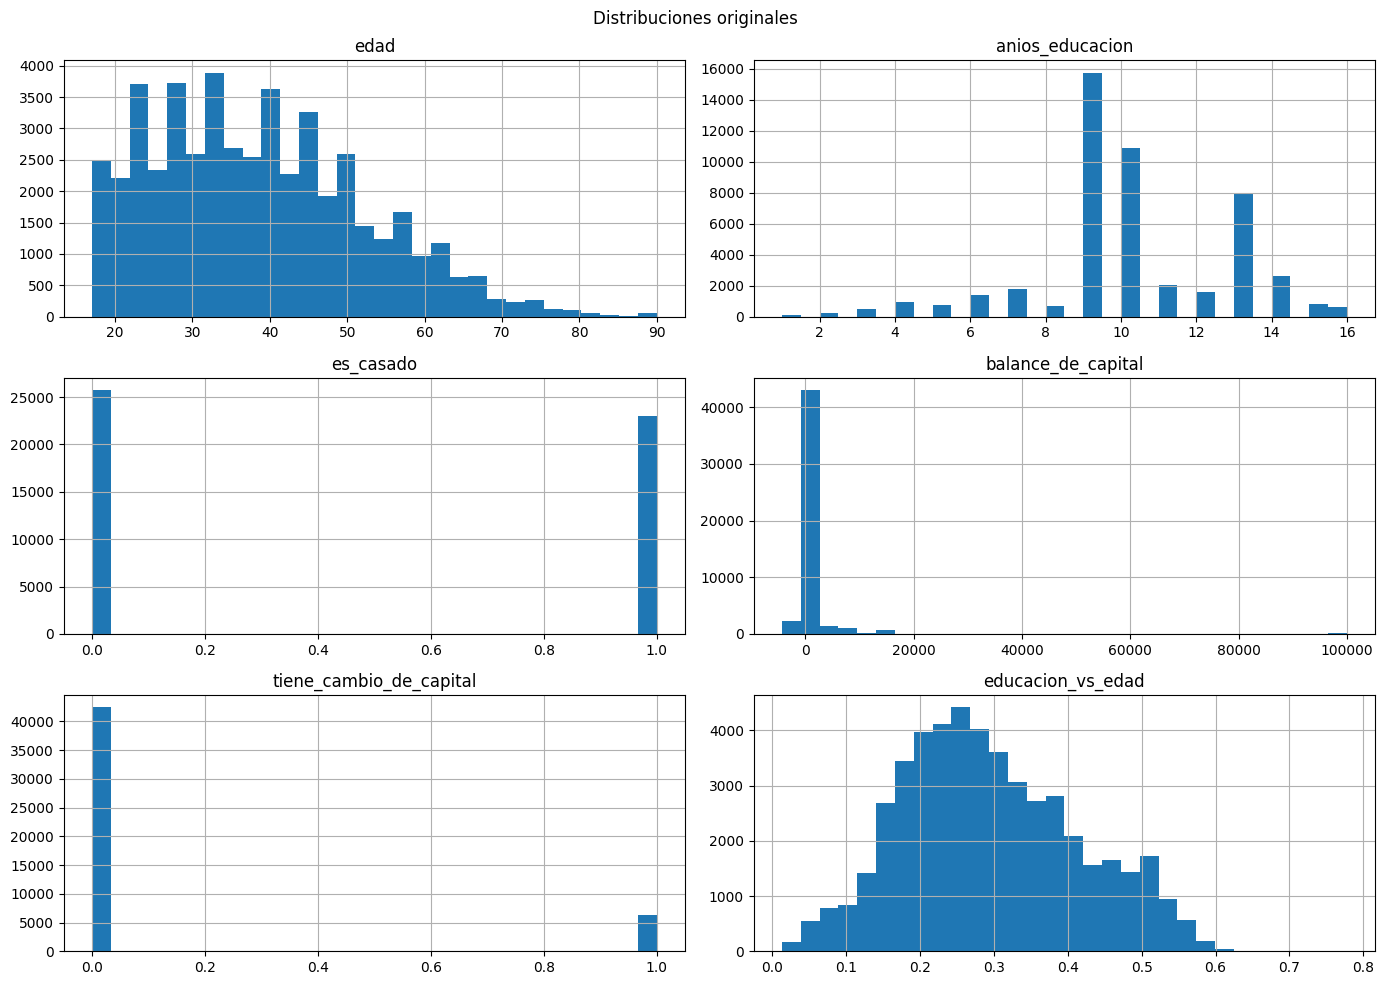

In [32]:
import matplotlib.pyplot as plt

df.select_dtypes(exclude=['object', 'category']).hist(figsize=(14, 10), bins=30)
plt.suptitle('Distribuciones originales')
plt.tight_layout()
plt.show()

## Lo que se observa en los gráficos de matplot

1. Edad
* La distribución está concentrada entre los 20 y 50 años.
* Hay una disminución gradual a partir de los 50 años.
* Existen pocos registros de personas mayores de 70 años.
* La distribución está sesgada a la derecha (cola hacia edades altas).
Conclusión: La muestra está compuesta principalmente por población en edad laboral activa.


2. Años de educación
* Se observan picos muy marcados en ciertos valores (especialmente 9, 10 y 13 años).
* Esto ocurre porque la variable representa niveles educativos discretos convertidos a años.
Conclusión: La mayoría de las personas tiene educación secundaria completa o algún nivel de educación superior, mientras que los niveles muy bajos o muy altos son menos frecuentes.

3. Estado civil
* Es una variable binaria (0 = no casado, 1 = casado).
* Las dos categorías tienen cantidades similares, aunque parece haber ligeramente más personas no casadas.
Conclusión: El estado civil está relativamente balanceado y puede ser una variable útil para modelos predictivos.

4. Balance de capital
* La inmensa mayoría de observaciones está cerca de cero.
* Existen pocos casos con valores extremadamente altos.
Conclusión: La variable presenta una fuerte asimetría positiva y contiene valores atípicos (outliers). Probablemente requeriría transformaciones (por ejemplo, logaritmo) antes de utilizarse en algunos modelos.

5. Tiene cambio de capital
* La mayoría de las observaciones son 0.
* Muy pocas personas registran ganancias o pérdidas de capital.
Conclusión: Es una variable altamente desbalanceada. La presencia de cambios de capital es un evento poco frecuente en la población.

6. Relación educación vs edad
* La distribución tiene forma aproximadamente unimodal.
* La mayor concentración está entre 0.2 y 0.4.
* Hay pocos valores extremos.

Interpretación:
* La mayoría de las personas acumula una proporción relativamente similar de educación respecto a su edad.
* Los valores altos pueden representar personas jóvenes con muchos años de educación.
* Los valores bajos pueden corresponder a personas de mayor edad con menor nivel educativo.

Conclusión: La variable parece capturar una medida de "intensidad educativa relativa a la edad" y podría aportar información adicional que no está presente en las variables originales por separado.


In [33]:
scaler = StandardScaler()
df_scaled_demo = scaler.fit_transform(df.select_dtypes(exclude=['object', 'category']).fillna(0))
df_scaled_demo[:3]

array([[ 0.02532779,  1.13664225, -0.94552723,  0.15795119,  2.59299113,
         0.33248569],
       [ 0.82775829,  1.13664225,  1.057611  , -0.13271439, -0.385655  ,
        -0.28482827],
       [-0.04762043, -0.41976611, -0.94552723, -0.13271439, -0.385655  ,
        -0.47976951]])

In [34]:
df.head()

,edad,tipo_trabajo,nivel_educativo,anios_educacion,estado_civil,ocupacion,relacion_familiar,sexo,ingresos,region,grupo_edad,horas_por_semana_grupo,es_casado,balance_de_capital,tiene_cambio_de_capital,educacion_vs_edad
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,2174,1,0.333333
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,<=50K,Norteamérica,Adulto,tiempo_parcial,1,0,0,0.260000
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,<=50K,Norteamérica,Adulto,estandar,0,0,0,0.236842
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,<=50K,Norteamérica,Adulto,estandar,1,0,0,0.132075
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,<=50K,Latinoamérica,Joven adulto,estandar,1,0,0,0.464286


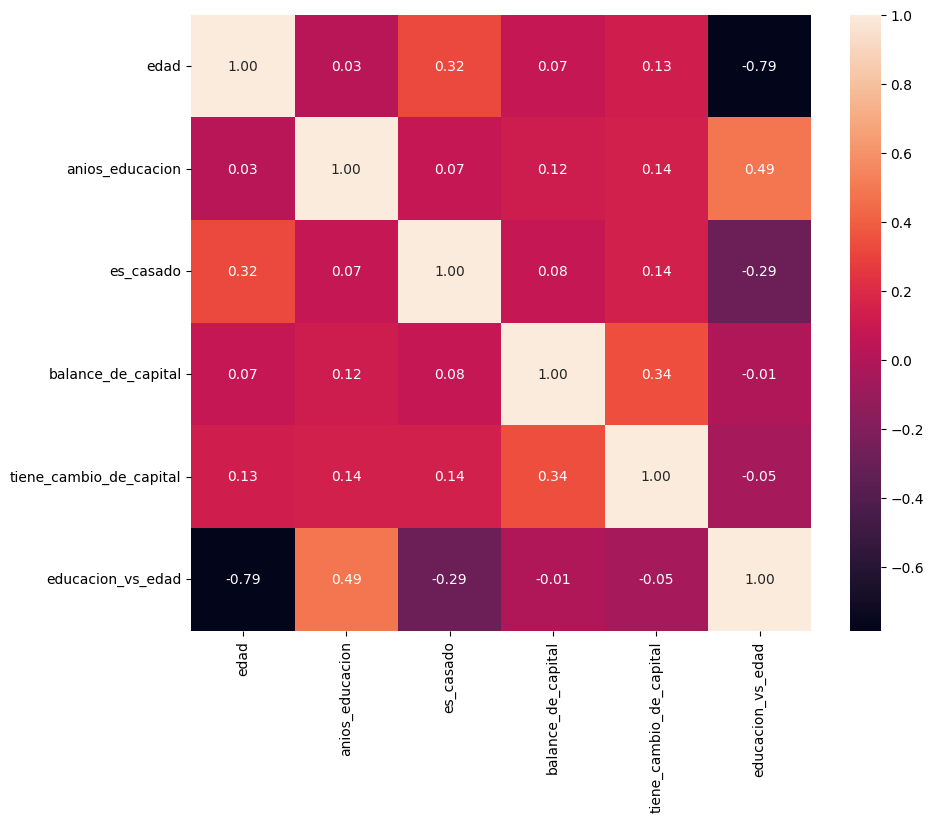

In [35]:
numfeat = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[numfeat].corr(), annot=True, fmt='.2f');

El heatmap muestra que no existe multicolinealidad fuerte entre las variables originales (ninguna supera ±0.7), lo cual es positivo para la construcción de modelos. La única relación muy fuerte es la de educacion_vs_edad con edad (-0.79), algo natural porque esa variable fue creada a partir de la edad y los años de educación.

Por tanto:

Edad, años de educación, estado civil y capital parecen aportar información relativamente complementaria.
educacion_vs_edad puede ser una variable útil, pero podría introducir redundancia con edad, por lo que se decide no incluir edad.


# MODELO NO SUPERVISADO DE CLUSTERIZACIÓN PARA INCLUSIÓN FINANCIERA

En esta sección se construye un modelo de clusterización usando:

- Pipeline
- ColumnTransformer
- OneHotEncoder
- StandardScaler
- KMeans
- PCA
- Silhouette Score

Objetivo:

Identificar perfiles similares de clientes para inclusión financiera sin usar un target supervisado.


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    OrdinalEncoder
)

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns


In [51]:

# VARIABLES PARA CLUSTERIZACIÓN

num_cols = [
    'edad',
    'anios_educacion',
    'es_casado',
    'tiene_cambio_de_capital',
    'educacion_vs_edad'
]

nominal_cols = [
    'tipo_trabajo',
    'ocupacion',
    'sexo',
    'region'
]

ordinal_cols = [
    'grupo_edad',
    'horas_por_semana_grupo'
]

X_cluster = df[
    num_cols + nominal_cols + ordinal_cols
].copy()

X_cluster.head()



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:

# PIPELINE NUMÉRICO

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_pipeline


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [39]:

# PIPELINE CATEGÓRICO NOMINAL

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='missing'
    )),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

nominal_pipeline


Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [40]:

# PIPELINE CATEGÓRICO ORDINAL

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

ordinal_pipeline


Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ordinal', OrdinalEncoder())])

In [41]:

# TRANSFORMADOR DE COLUMNAS

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['edad', 'anios_educacion', 'es_casado',
                                  'tiene_cambio_de_capital',
                                  'educacion_vs_edad']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['tipo_trabajo', 'ocupacion', 'sexo',
                                  'region']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder())]),
                                 ['grupo_edad', 'horas_por_semana_grupo'])])

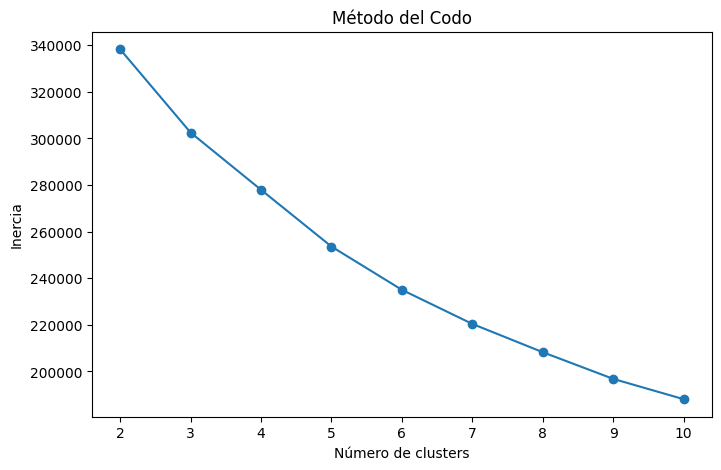

In [42]:

# MÉTODO DEL CODO

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_cluster)

    inertia.append(
        pipe.named_steps['model'].inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

plt.show()


# Elección de número de cluster

El método del codo sugiere utilizar aproximadamente 5 clusters, ya que a partir de ese punto la reducción de la inercia es cada vez menor y agregar más grupos aporta beneficios marginales. Se va a revisar el método Silhouett Score.

In [43]:

# SILHOUETTE SCORE (Que tan buena es la separación entre los clusters)

X_processed = preprocessor.fit_transform(X_cluster)

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_processed)

    score = silhouette_score(
        X_processed,
        labels
    )

    print(f'Clusters: {k} | Silhouette Score: {score:.3f}')


Clusters: 2 | Silhouette Score: 0.270
Clusters: 3 | Silhouette Score: 0.272
Clusters: 4 | Silhouette Score: 0.249
Clusters: 5 | Silhouette Score: 0.215
Clusters: 6 | Silhouette Score: 0.213
Clusters: 7 | Silhouette Score: 0.215
Clusters: 8 | Silhouette Score: 0.218
Clusters: 9 | Silhouette Score: 0.226
Clusters: 10 | Silhouette Score: 0.200


El Método del Codo sugiere que el punto de inflexión se encuentra alrededor de 5 clusters. Sin embargo, el análisis mediante Silhouette Score muestra que el valor máximo se alcanza con 3 clusters (0.272). Por lo tanto, se selecciona k=4 como el número óptimo de clusters, ya que proporciona la mejor separación y cohesión entre grupos.

##MODELO FINAL

In [44]:

# MODELO FINAL

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', kmeans)
])

cluster_pipeline.fit(X_cluster)

clusters = cluster_pipeline.predict(X_cluster)

df['cluster'] = clusters

df[['cluster']].head()


,cluster
0,2
1,1
2,1
3,1
4,3


## TAMAÑO DE LOS CLUSTERS

In [45]:

# TAMAÑO DE LOS CLUSTERS

df.groupby('cluster').size()


,0
cluster,
0,3916
1,21958
2,6093
3,16823


Interpretación
* El Cluster 1 es el grupo dominante, concentrando aproximadamente el 45% de los individuos.
* El Cluster 3 es el segundo grupo más grande, con cerca del 34.5% de los registros.
* Los Clusters 0 y 2 son considerablemente más pequeños (8% y 12.5%), lo que sugiere que representan perfiles más específicos o menos frecuentes dentro de la población.

Se tienen entonces clústers de tamaños desiguales. Los clusters 1 y 3 concentran cerca del 80% de la población analizada, mientras que los clusters 0 y 2 representan segmentos más reducidos y específicos. Aunque existe cierto desbalance en el tamaño de los grupos, ninguno de ellos es demasiado pequeño, por lo que todos pueden considerarse estadísticamente relevantes para el análisis posterior. Además, esta distribución sugiere la presencia de perfiles poblacionales predominantes y otros más particulares dentro del conjunto de datos.

## PERFIL NUMÉRICO DE LOS CLUSTERS

In [46]:

# PERFIL NUMÉRICO POR CLUSTER

df.groupby('cluster')[num_cols].mean()


,edad,anios_educacion,es_casado,tiene_cambio_de_capital,educacion_vs_edad
cluster,,,,,
0,22.807201,9.489019,0.089122,0.041113,0.427033
1,48.650150,10.028828,0.590263,0.000000,0.215363
2,44.046775,11.070080,0.679140,1.000000,0.272856
3,27.338762,9.922309,0.331808,0.003745,0.372855


###Interpretación de cada clúster desde las variables numéricas

**Cluster 0:** Jóvenes solteros en formación.
Es el grupo más joven (22.8 años).
Muy pocos están casados (9%).
Nivel educativo medio.
Alta relación educación/edad (0.43).

Interpretación:

Personas jóvenes, probablemente iniciando su vida laboral o terminando estudios, con poca presencia de matrimonio y escasa actividad de capital.

**Cluster 1:** Adultos maduros y estables.
Mayor edad promedio (48.7 años).
59% casados.
Prácticamente sin cambios de capital.
Menor relación educación/edad.

Interpretación:

Adultos de mayor edad con una situación personal más estable, posiblemente con trayectoria laboral consolidada.

**Cluster 2:** Adultos con mayor nivel educativo y actividad de capital.
Edad media (44 años).
Mayor nivel educativo (11.1 años).
Mayor proporción de casados (68%).
Todos presentan cambio de capital (valor promedio = 1).

Interpretación:

Es el segmento económicamente más activo. Tiene el mayor nivel educativo y es el único cluster claramente asociado a movimientos de capital.

**Cluster 3:** Adultos jóvenes en transición.
Edad promedio de 27 años.
33% casados.
Educación similar al promedio.
Sin cambios de capital relevantes.

Interpretación:

Personas jóvenes adultas, probablemente en una etapa de consolidación laboral y familiar.

##PERFIL CATEGÓRICO POR CLUSTERS

In [47]:

# PERFIL CATEGÓRICO POR CLUSTER

for col in nominal_cols:

    print(f'\n===== {col} =====')

    print(
        pd.crosstab(
            df['cluster'],
            df[col],
            normalize='index'
        )
    )



===== tipo_trabajo =====
tipo_trabajo  Federal-gov  Local-gov  Never-worked   Private  Self-emp-inc  \
cluster                                                                      
0                0.010981   0.031154      0.000766  0.723698      0.011236   
1                0.038118   0.078559      0.000000  0.636078      0.043538   
2                0.038569   0.073691      0.000000  0.636960      0.072378   
3                0.018843   0.049932      0.000416  0.783332      0.015039   

tipo_trabajo  Self-emp-not-inc  State-gov  Without-pay   unknown  
cluster                                                           
0                     0.036006   0.058989     0.000766  0.126404  
1                     0.106749   0.044949     0.000546  0.051462  
2                     0.098802   0.038405     0.000492  0.040702  
3                     0.046008   0.031445     0.000178  0.054806  

===== ocupacion =====
ocupacion  Adm-clerical  Armed-Forces  Craft-repair  Exec-managerial  \
cluster 

###Interpretación de cada clúster desde las variables categóricas

**Cluster 0:**
* Predominan trabajadores del sector privado.
* Alta participación en ocupaciones de servicios y ventas.
* Es el único cluster con mayoría femenina (56%).

Interpretación: Segmento joven, con empleos de menor especialización y menor madurez financiera relativa.

**Cluster 1:**
* Predomina el empleo privado.
* Mayor presencia de ocupaciones técnicas, administrativas y de reparación.
* Mayoritariamente masculino (69%).

Interpretación: Segmento laboralmente consolidado y relativamente estable.

**Cluster 2:**
* Mayor proporción de ocupaciones profesionales (Prof-specialty) y gerenciales (Exec-managerial).
* Mayor participación de trabajo independiente y emprendimiento.
* Mayor predominio masculino (78%).

Interpretación: Es el cluster con el perfil ocupacional más calificado y con mayor potencial económico.

**Cluster 3:**
* Fuerte predominio del empleo privado (78%).
* Mayor presencia de trabajos operativos y de servicios.
* Perfil intermedio entre los clusters 0 y 1.

Interpretación: Segmento joven en proceso de consolidación laboral.

**Hallazgo transversal**
* En todos los clusters predomina ampliamente Norteamérica (≈94%), por lo que la región no parece ser una variable diferenciadora.
* La principal diferenciación entre clusters proviene de:
Edad.
Nivel educativo.
Estado civil.
Tipo de ocupación.
Participación en actividades de capital.

##VISUALIZACIÓN POR PCA

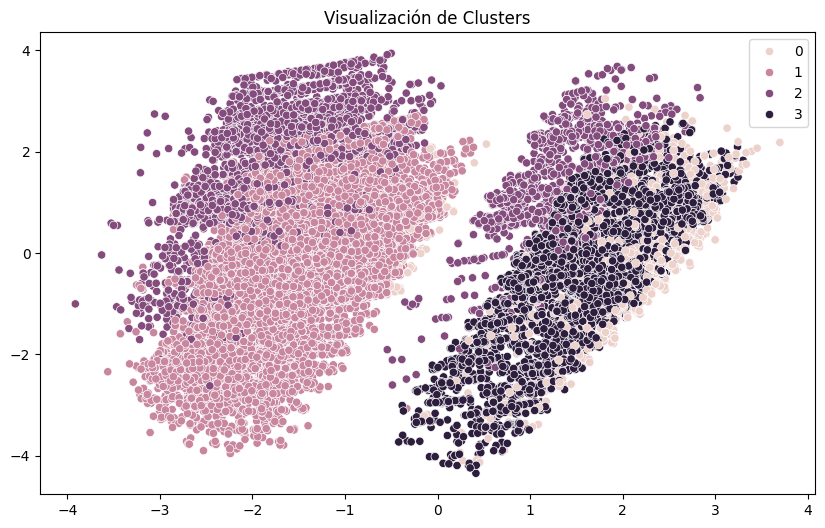

In [48]:

# VISUALIZACIÓN CON PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters
)

plt.title('Visualización de Clusters')

plt.show()



#RECOMENDACIONES PARA EL NEGOCIO

Interpretación de los clusters desde la perspectiva de inclusión financiera, compilando lo encontrado para cada clúster tanto en las variables numéricas como en las categóricas, que se mencionan mas arriba:

| Prioridad | Cluster   | Estrategia                                 |
| --------- | --------- | ------------------------------------------ |
| 1         | Cluster 2 | Oferta de crédito                          |
| 2         | Cluster 1 | Crédito conservador + educación financiera |
| 3         | Cluster 3 | Educación financiera + microcrédito        |
| 4         | Cluster 0 | Educación financiera principalmente        |





El objetivo de este modelo no es aprobar o rechazar automáticamente como lo hacen los modelos Supervisados, a partir de una Target de "Default", sino entender perfiles socioeconómicos similares para acompañarlos y a partir de ahí aumentar la inclusión financiera crediticia para ellos.

La segmentación permite identificar grupos con diferentes niveles de madurez financiera. Sin embargo, al no contar con historial crediticio ni variables directas de capacidad de pago, las recomendaciones deben interpretarse como una priorización preliminar para estrategias de inclusión financiera y no como una decisión definitiva de originación de crédito.



# MÉTRICAS DE EVALUACIÓN DEL MODELO

Se van a revisar las siguientes métricas de clusterización: { - -Silhouette Score
-Davier
-Calinski-Harabasz

In [49]:

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


##MÉTRICAS DE CLUSTERIZACIÓN

In [50]:

# MÉTRICAS DE CLUSTERIZACIÓN

silhouette = silhouette_score(X_processed, clusters)

davies = davies_bouldin_score(X_processed.toarray(), clusters)

calinski = calinski_harabasz_score(X_processed.toarray(), clusters)

print(f'Silhouette Score: {silhouette:.3f}')
print(f'Davies-Bouldin Index: {davies:.3f}')
print(f'Calinski-Harabasz Score: {calinski:.3f}')


Silhouette Score: 0.249
Davies-Bouldin Index: 1.537
Calinski-Harabasz Score: 11267.192



# INTERPRETACIÓN DE MÉTRICAS

## Silhouette Score

Rango:

- cercano a 1 → clusters bien separados
- cercano a 0 → clusters mezclados
- negativo → mala clusterización

Generalmente:

- > 0.50 = muy bueno
- 0.25 - 0.50 = aceptable
- < 0.25 = débil

Los clusters presentan cierta diferenciación, pero existen zonas de solapamiento entre ellos. Los grupos no están completamente separados.

---

## Davies-Bouldin

Mientras MÁS BAJO mejor.

Mide:
- similitud entre clusters

Este indicador da muy bajo en el modelo, lo que indica que los cluster no son similares.

---

## Calinski-Harabasz

Mientras MÁS ALTO mejor.

Mide:
- separación entre grupos
- cohesión interna

Este indicador está dando un número muy alto, lo que sugiere separación entre grupos y cohesión al interior de cada cluster.